In [2]:
#Basic Lib
import numpy as np
import pandas as pd

#Visualization lib
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation lib
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

#Deep Learning Lib
import tensorflow as tf
from tensorflow.keras import layers 
import keras
from keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Dropout
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier

In [3]:
#Digit MNIST Dataset
(x_train_digit,y_train_digit),(x_test_digit,y_test_digit)=mnist.load_data()

x_train_digit → images of handwritten digits

y_train_digit → labels for those images

x_test_digit → test images

y_test_digit → test labels

In [4]:
print(y_train_digit[0])

5


In [5]:
#Names of Numbers in the dataset in order
col_names=['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

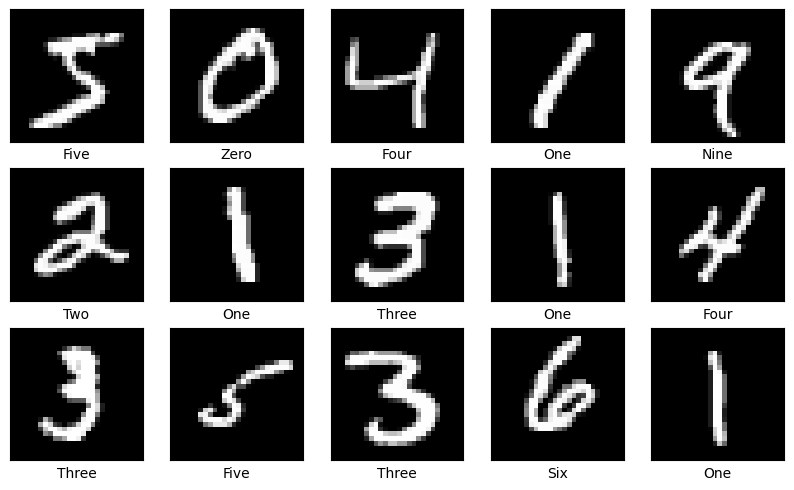

In [6]:
#Visualizing the digits
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train_digit[i],cmap='gray') #imshow() converts that matrix into an image.
    plt.xlabel(col_names[y_train_digit[i]])
plt.show()


In [7]:
x_train_digit.shape

(60000, 28, 28)

In [8]:
#COnverting 3D-2D Cuz ANN Accept 2D only 
x_train_digit=x_train_digit.reshape(60000,784)
x_test_digit=x_test_digit.reshape(10000,784)

In [9]:
x_train_digit.shape

(60000, 784)

In [10]:
y_train_digit.shape

(60000,)

In [11]:
#Encoding Digit MNIST Label
y_train_digit=to_categorical(y_train_digit,num_classes=10)
y_test_digit=to_categorical(y_test_digit,num_classes=10)

In [12]:
#Creating base Neural Network

model=Sequential([
    layers.Dense(256,activation='relu',input_shape=(784,)),
    layers.Dense(64,activation='relu'),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='sigmoid'),
])

C:\Users\USER\anaconda3\envs\aiml\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#Compiling the model 
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

In [17]:
history=model.fit(x_train_digit,y_train_digit,batch_size=100,epochs=10,validation_data=(x_test_digit,y_test_digit))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8324 - loss: 1.4274 - val_accuracy: 0.9075 - val_loss: 0.3587
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9195 - loss: 0.2458 - val_accuracy: 0.8957 - val_loss: 0.2329
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9283 - loss: 0.1533 - val_accuracy: 0.9354 - val_loss: 0.2027
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9389 - loss: 0.1250 - val_accuracy: 0.9175 - val_loss: 0.1825
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9325 - loss: 0.1039 - val_accuracy: 0.9503 - val_loss: 0.1470
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9294 - loss: 0.0916 - val_accuracy: 0.9053 - val_loss: 0.1698
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9271 - loss: 0.0944 - val_accuracy: 0.9094 - val_loss: 0.1531
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9161 - loss: 0.0840 - val_accuracy: 0.

In [21]:
#PreProcessing the Ouutput
#Predicting the Label-DIGIT
y_predict=model.predict(x_test_digit)

y_predicts=np.argmax(y_predict,axis=1)
y_test_digit_eval=np.argmax(y_test_digit,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


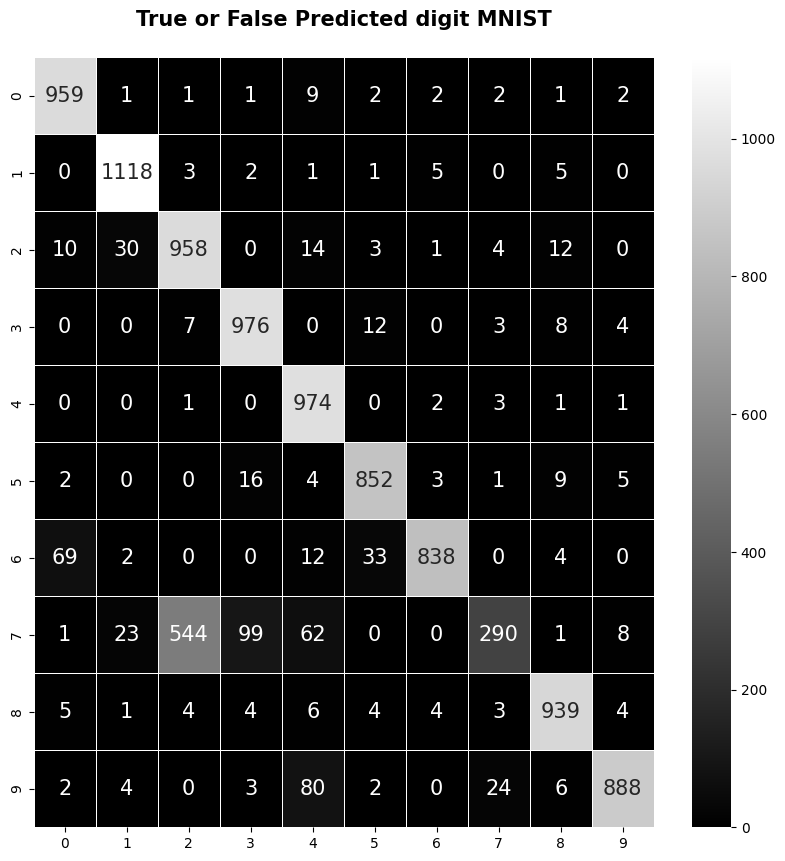

In [27]:
#Confusion Matrix for Digit MNIST

con_mat=confusion_matrix(y_test_digit_eval,y_predicts)
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidths=0.5,fmt='d',cmap='gray')
plt.title('True or False Predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()

In [29]:
#Classification Report 

from sklearn.metrics import classification_report
print(classification_report(y_test_digit_eval,y_predicts))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95       980
           1       0.95      0.99      0.97      1135
           2       0.63      0.93      0.75      1032
           3       0.89      0.97      0.92      1010
           4       0.84      0.99      0.91       982
           5       0.94      0.96      0.95       892
           6       0.98      0.87      0.92       958
           7       0.88      0.28      0.43      1028
           8       0.95      0.96      0.96       974
           9       0.97      0.88      0.92      1009

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.87     10000
weighted avg       0.89      0.88      0.87     10000



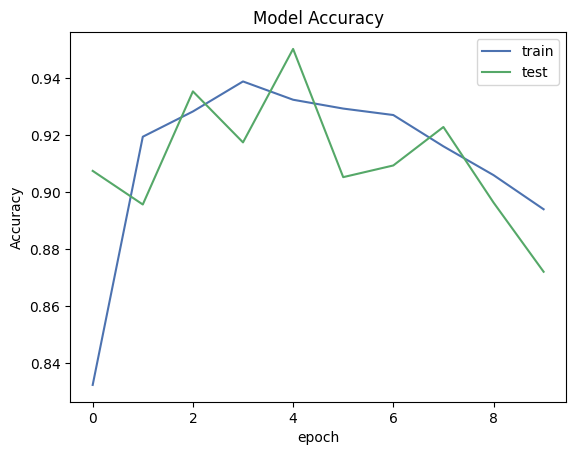

In [30]:
#Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='best')
plt.show()

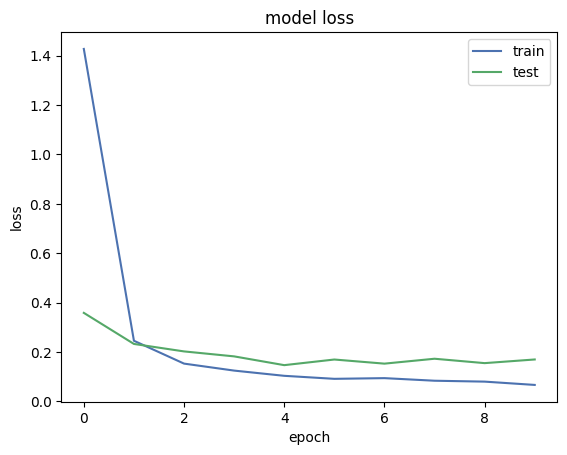

In [31]:
#Loss Graph

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='best')
plt.show()